<a href="https://colab.research.google.com/github/devikamj04/Data-Science-Lab/blob/main/Lab9B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Iris Flower Analysis and Naïve Bayes Classification
Using the Iris.csv dataset:

1.	Perform basic EDA by displaying the first five records, missing values, descriptive statistics, and species distribution.
2.	Plot a scatter plot of Sepal Length vs Sepal Width, a histogram of Sepal Length, and a box plot of Sepal Length by Species.
3.	Apply Gaussian Naïve Bayes to predict Species using the numerical features, with an 80:20 train-test split.
4.	Display the classification report and accuracy



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
iris_df = pd.read_csv('/content/Iris - Iris.csv')

### 1. Basic EDA

#### Displaying the first five records

In [ ]:
display(iris_df.head())

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


#### Checking for missing values

In [ ]:
display(iris_df.isnull().sum())

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


#### Displaying descriptive statistics

In [ ]:
display(iris_df.describe())

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


#### Displaying species distribution

In [ ]:
display(iris_df['Species'].value_counts())

,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


### 2. Plotting Visualizations

#### Scatter plot of Sepal Length vs Sepal Width

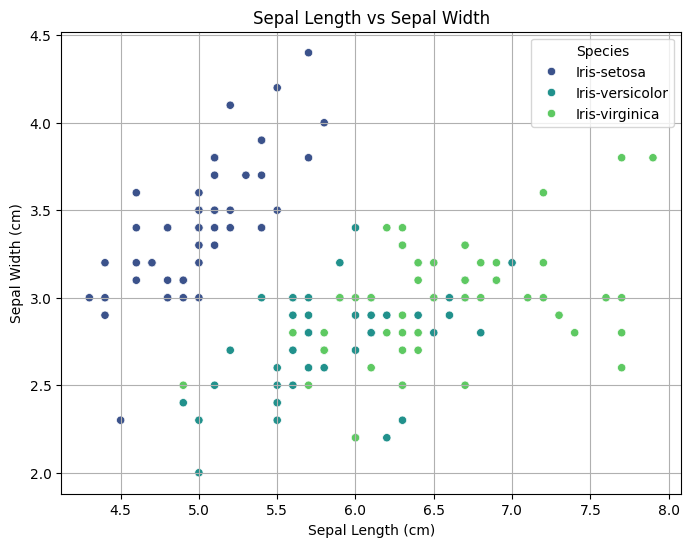

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='SepalLengthCm', y='SepalWidthCm', hue='Species', data=iris_df, palette='viridis')
plt.title('Sepal Length vs Sepal Width')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.grid(True)
plt.show()

#### Histogram of Sepal Length

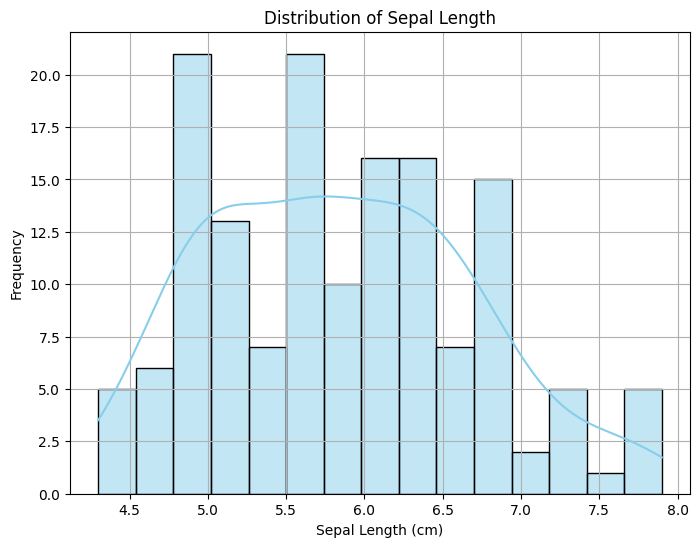

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(iris_df['SepalLengthCm'], kde=True, bins=15, color='skyblue')
plt.title('Distribution of Sepal Length')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

#### Box plot of Sepal Length by Species

/tmp/ipykernel_3833/4009748715.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Species', y='SepalLengthCm', data=iris_df, palette='viridis')


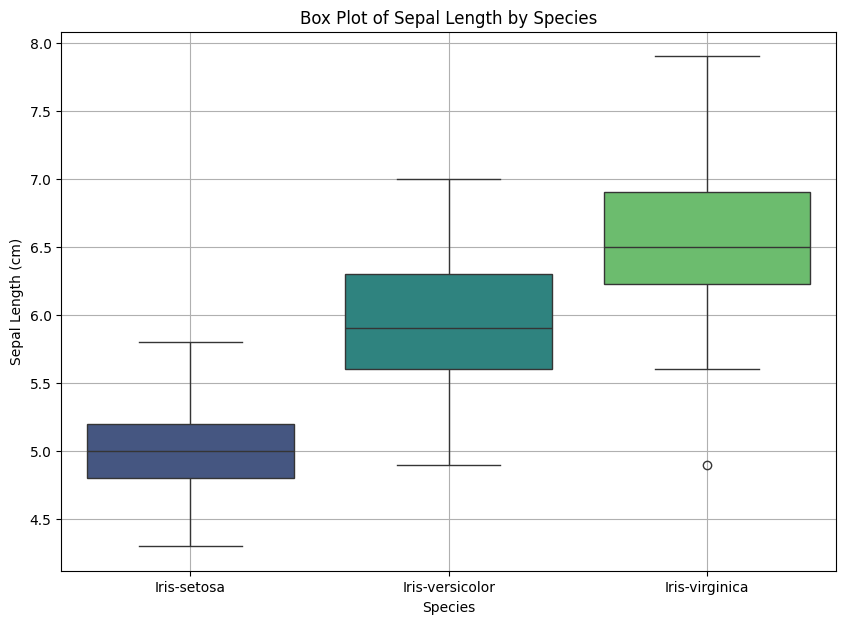

In [ ]:
plt.figure(figsize=(10, 7))
sns.boxplot(x='Species', y='SepalLengthCm', data=iris_df, palette='viridis')
plt.title('Box Plot of Sepal Length by Species')
plt.xlabel('Species')
plt.ylabel('Sepal Length (cm)')
plt.grid(True)
plt.show()

### 3. Applying Gaussian Naïve Bayes

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score

# Define features (X) and target (y)
X = iris_df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
y = iris_df['Species']

# Split the data into training and testing sets (80:20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Gaussian Naïve Bayes classifier
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Make predictions on the test set
y_pred = gnb.predict(X_test)

### 4. Displaying Classification Report and Accuracy

#### Classification Report

In [ ]:
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



#### Accuracy Score

In [ ]:
print(f'Accuracy: {accuracy_score(y_test, y_pred):.2f}')

Accuracy: 1.00
